# Preamble

In [1]:
import warnings
import logging
import kagglehub
import os
import time
import platform
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mlflow
from mlflow.client import MlflowClient
from  sklearn.metrics import mean_absolute_error, mean_squared_error, \
    root_mean_squared_log_error
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse 
import statsforecast as sf_pkg
from neuralforecast.utils import PredictionIntervals

os.environ["MLFLOW_ENABLE_SYSTEM_METRICS_LOGGING"] = "true"

logging.getLogger("mlflow").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# Enable PyTorch Lightning autologging
mlflow.pytorch.autolog(
    log_every_n_epoch=1,
    log_models=True,
    disable=False
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

experiment_name = "store_sales_forecasting"

In [2]:
# Callable function to compute RMSLE using utilsforecast evaluate function
def rmsle(df, models, id_col='unique_id', target_col='y'):
    out = {id_col: [], 'metric': []}
    for uid, g in df.groupby(id_col):
        out[id_col].append(uid)
        out['metric'].append('rmsle')
        for m in models:
            out.setdefault(m, []).append(
                root_mean_squared_log_error(g[target_col], g[m])
            )
    return pd.DataFrame(out)

mlflow server --backend-store-uri sqlite:///mlflow.db \ 
    --default-artifact-root ./mlartifacts  \
    --host 127.0.0.1 --port 5000

In [3]:
from pathlib import Path

# Resolve project root dynamically
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

db_path = project_root / "mlflow.db"
artifact_path = project_root / "mlartifacts"

# Set tracking URI to SQLite
mlflow.set_tracking_uri(f"sqlite:///{db_path.as_posix()}")

# Create experiment with explicit artifact destination
client = MlflowClient()

experiment = client.get_experiment_by_name(experiment_name)
if experiment is None:
    client.create_experiment(
        name=experiment_name,
        artifact_location=artifact_path.as_uri()
    )

mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='file:///home/on1link/Applications/projects/store_sales/store_sales_forecasting/mlartifacts', creation_time=1787761182352, effective_trace_archival_retention=None, experiment_id='6', last_update_time=1787761182352, lifecycle_stage='active', name='store_sales_forecasting', tags={}, trace_location=None, workspace='default'>

In [4]:
kagglehub.login()

In [5]:
competition_name = "store-sales-time-series-forecasting"
path = kagglehub.competition_download(competition_name)

In [6]:
type(path)
print("".join([path, '/train.csv']))

/home/on1link/.cache/kagglehub/competitions/store-sales-time-series-forecasting/train.csv


# Data Ingestion

In [7]:
train_path = "".join([path, '/train.csv'])

In [8]:
train = pd.read_csv("".join([path, '/train.csv']), parse_dates=['date'])
stores = pd.read_csv("".join([path, '/stores.csv']))

# Exploratory Data Analysis

## Dataset Overview

In [9]:
print(train.head(5), "\n", train.tail(5))

   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0 
               id       date  store_nbr                      family     sales  \
3000883  3000883 2017-08-15          9                     POULTRY   438.133   
3000884  3000884 2017-08-15          9              PREPARED FOODS   154.553   
3000885  3000885 2017-08-15          9                     PRODUCE  2419.729   
3000886  3000886 2017-08-15          9  SCHOOL AND OFFICE SUPPLIES   121.000   
3000887  3000887 2017-08-15          9                     SEAFOOD    16.000   

         onpromotion  
3000883            0  
3000884            1  
3000885          148  
3000886            8  
3000887            0  


In [10]:
print(train.columns)

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')


In [11]:
train.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [13]:
print(f"Unique stores and ids: {train['store_nbr'].nunique()} \n {train['store_nbr'].sort_values().unique()[:]}")

Unique stores and ids: 54 
 [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54]


In [14]:
print(f"Number of categories or families and names: {train['family'].nunique()} \n {train['family'].unique()[:]}")


Number of categories or families and names: 33 
 ['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


## Feature Engineering

In [15]:
train['unique_id'] = 'store_' + train['store_nbr'].astype('str') + '_' + train['family']

In [16]:
print(train.columns)
print(stores.columns)

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion',
       'unique_id'],
      dtype='object')
Index(['store_nbr', 'city', 'state', 'type', 'cluster'], dtype='object')


In [17]:
train.head(5)

,id,date,store_nbr,family,sales,onpromotion,unique_id
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,store_1_AUTOMOTIVE
1,1,2013-01-01,1,BABY CARE,0.0,0,store_1_BABY CARE
2,2,2013-01-01,1,BEAUTY,0.0,0,store_1_BEAUTY
3,3,2013-01-01,1,BEVERAGES,0.0,0,store_1_BEVERAGES
4,4,2013-01-01,1,BOOKS,0.0,0,store_1_BOOKS


In [18]:
print(f"Unique Time Series Count: {train['unique_id'].nunique()}")

Unique Time Series Count: 1782


In [19]:
print(f"Date range: {train['date'].min()} - {train['date'].max()}")

Date range: 2013-01-01 00:00:00 - 2017-08-15 00:00:00


# Zero sales analysis (store, family, day of the week)

In [20]:
zero_rate = (train['sales'] == 0).mean()
print(f"{(100*zero_rate):.2f}%")

31.30%


## Zero sales rate per store

In [21]:
zero_by_store = (train.groupby('store_nbr')['sales']).apply(lambda x: (x == 0).mean())
print(zero_by_store.sort_values(ascending=False).head(5)*100)

store_nbr
52    93.539912
22    68.548910
42    62.216584
21    61.300655
29    57.217664
Name: sales, dtype: float64


In [22]:
zero_sales_store_distribution = train.assign(is_zero=(train['sales'] == 0), sales_status=np.where(train['sales'] == 0, 'Zero Sales', 'Positive Sales'))

<Axes: xlabel='store_nbr'>

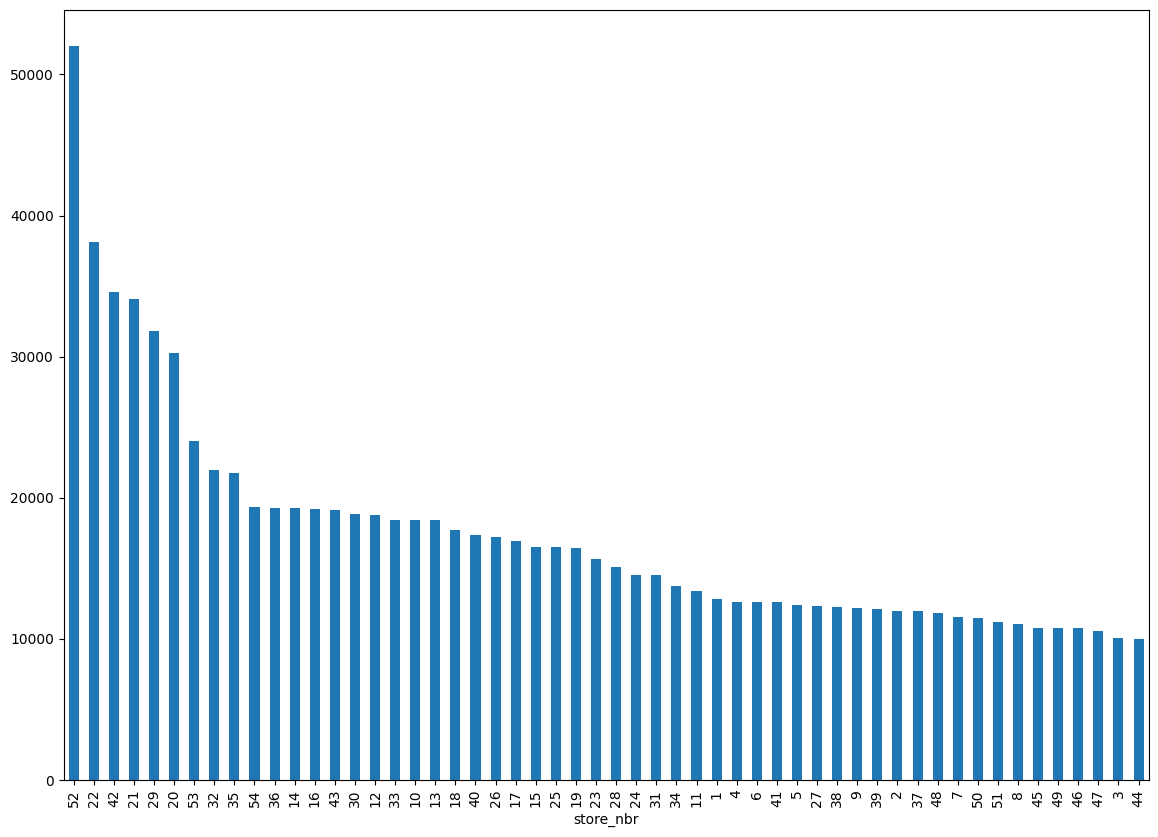

In [23]:
zero_sales_store_distribution.groupby('store_nbr')['is_zero'].sum().sort_values(ascending=False).plot.bar(figsize=(14,10))

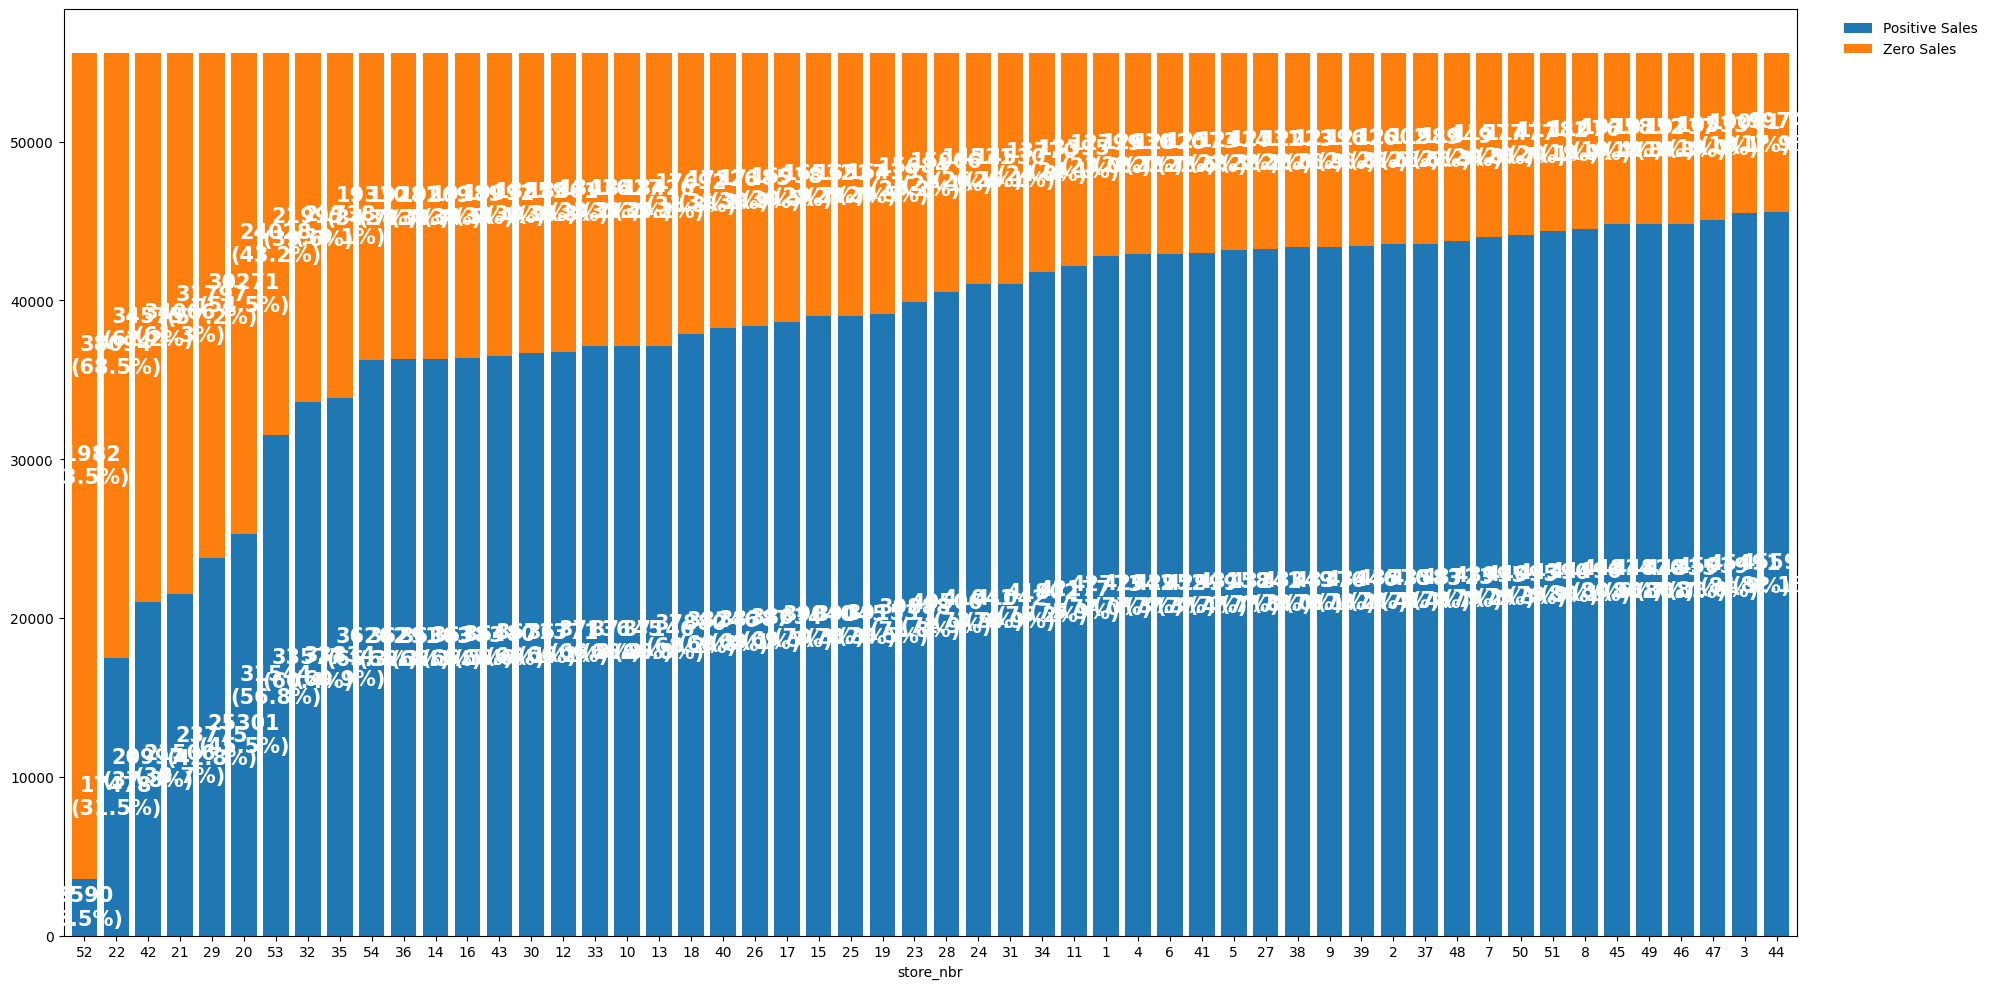

In [24]:
plot_data = (zero_sales_store_distribution.groupby(['store_nbr', 'sales_status']).size().unstack(fill_value=0).sort_values(by='Zero Sales', ascending=False))
ax = plot_data.plot.bar(
    stacked=True, figsize=(20,10), width=0.8, edgecolor='none'
)

daily_totals = plot_data.sum(axis=1) # Total records per store

for container in ax.containers:
    labels= [
        f"{val:g}\n({(val / total) * 100:.1f}%)" if val > 0 else ""
        for val, total in zip(container.datavalues, daily_totals)
    ]
    ax.bar_label(container, labels=labels, label_type='center', color='white', weight='bold', fontsize=15)


plt.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

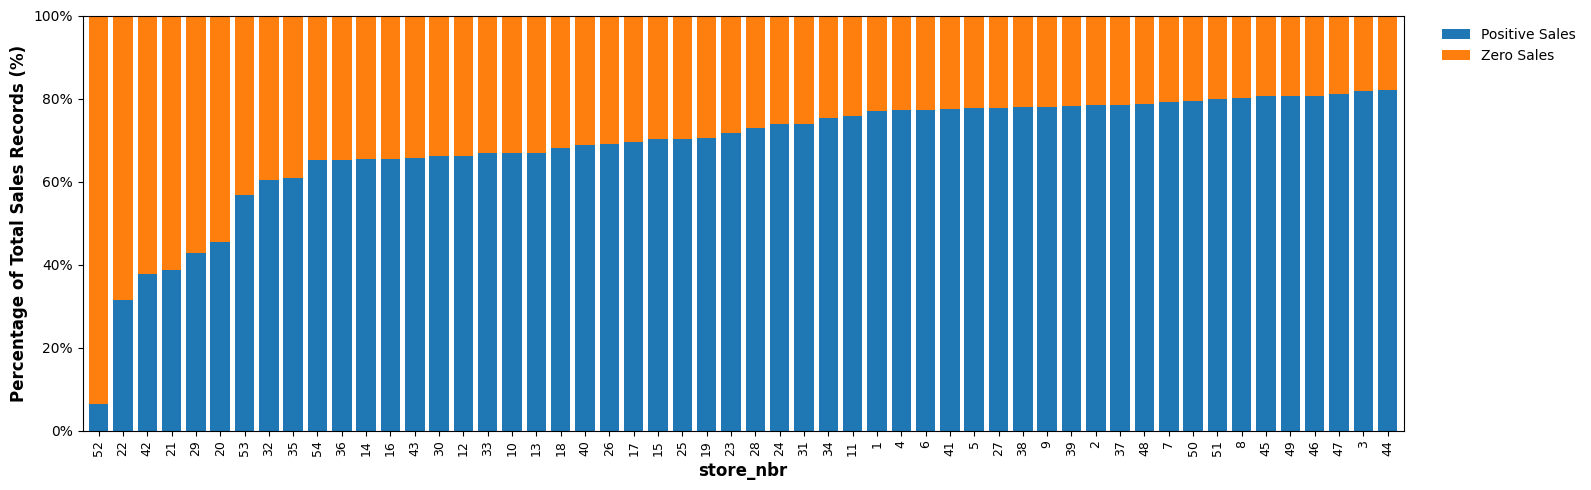

In [25]:
# 1. Group and unstack, then calculate percentages per store
plot_data = (
    zero_sales_store_distribution.groupby(['store_nbr', 'sales_status'])
    .size()
    .unstack(fill_value=0)
    .sort_values(by='Zero Sales', ascending=False)
)

# Convert counts to proportions/percentages per store row
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

# 2. Plot as a 100% stacked bar chart
ax = plot_data_pct.plot.bar(
    stacked=True, 
    figsize=(16, 5), 
    width=0.8, 
    edgecolor='none'
)

# 3. Format y-axis as percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
plt.ylim(0, 100)

# 4. Styling
plt.ylabel("Percentage of Total Sales Records (%)", fontsize=12, weight='bold')
plt.xlabel("store_nbr", fontsize=12, weight='bold')
plt.xticks(rotation=90, fontsize=9)
plt.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Top 10 stores with most zeros days sales (plotbar)

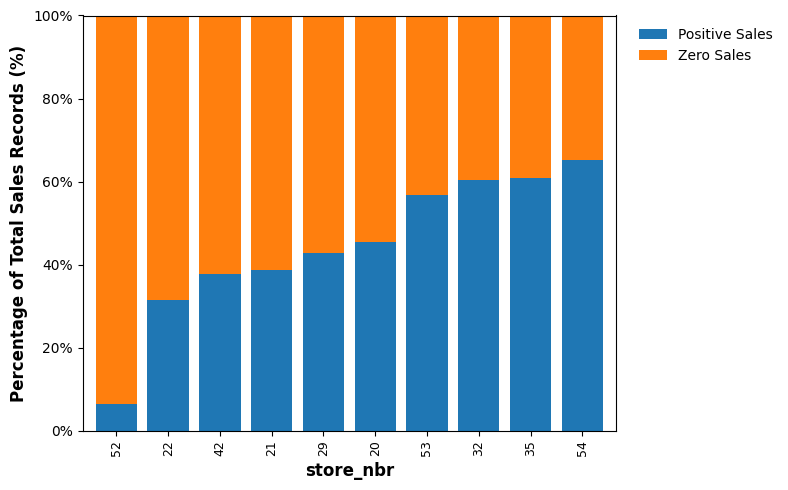

In [26]:
 
plot_data = (
    zero_sales_store_distribution.groupby(['store_nbr', 'sales_status'])
    .size()
    .unstack(fill_value=0)
    .sort_values(by='Zero Sales', ascending=False)[:10]
)

# Convert counts to proportions/percentages per store row
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

# 2. Plot as a 100% stacked bar chart
ax = plot_data_pct.plot.bar(
    stacked=True, 
    figsize=(8, 5), 
    width=0.8, 
    edgecolor='none'
)

# 3. Format y-axis as percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
plt.ylim(0, 100)

# 4. Styling
plt.ylabel("Percentage of Total Sales Records (%)", fontsize=12, weight='bold')
plt.xlabel("store_nbr", fontsize=12, weight='bold')
plt.xticks(rotation=90, fontsize=9)
plt.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

<Axes: xlabel='store_nbr'>

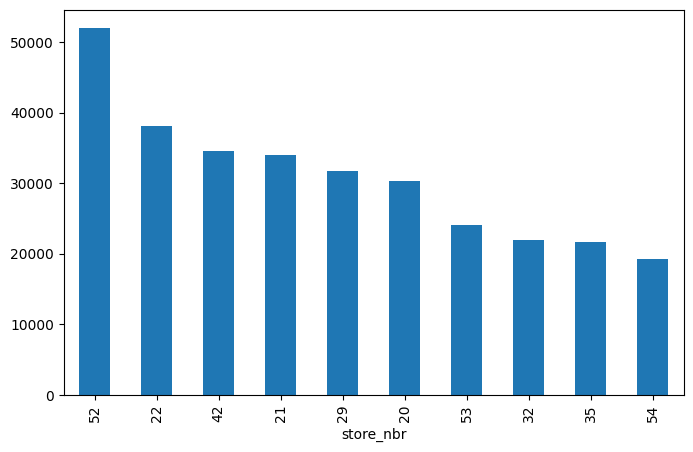

In [27]:
zero_sales_store_distribution.groupby('store_nbr')['is_zero'].sum().sort_values(ascending=False)[:10].plot.bar(figsize=(8, 5))

In [28]:
zero_sales_store_distribution.groupby

<bound method DataFrame.groupby of               id       date  store_nbr                      family     sales  \
0              0 2013-01-01          1                  AUTOMOTIVE     0.000   
1              1 2013-01-01          1                   BABY CARE     0.000   
2              2 2013-01-01          1                      BEAUTY     0.000   
3              3 2013-01-01          1                   BEVERAGES     0.000   
4              4 2013-01-01          1                       BOOKS     0.000   
...          ...        ...        ...                         ...       ...   
3000883  3000883 2017-08-15          9                     POULTRY   438.133   
3000884  3000884 2017-08-15          9              PREPARED FOODS   154.553   
3000885  3000885 2017-08-15          9                     PRODUCE  2419.729   
3000886  3000886 2017-08-15          9  SCHOOL AND OFFICE SUPPLIES   121.000   
3000887  3000887 2017-08-15          9                     SEAFOOD    16.000   

    

# Distribution per family

In [29]:
zero_by_family = train.groupby('family')['sales'].apply(lambda x: (x==0).mean())
print(zero_by_family.sort_values(ascending=False).head(5)*100)

family
BOOKS                         96.955001
BABY CARE                     94.131037
SCHOOL AND OFFICE SUPPLIES    74.082871
HOME APPLIANCES               73.517639
LADIESWEAR                    59.846485
Name: sales, dtype: float64


In [30]:
zero_sales_family_distribution = train.assign(is_zero= (train["sales"] == 0), sales_status=np.where(train["sales"] == 0, "Zero Sales", "Positive Sales"))


<Axes: xlabel='store_nbr'>

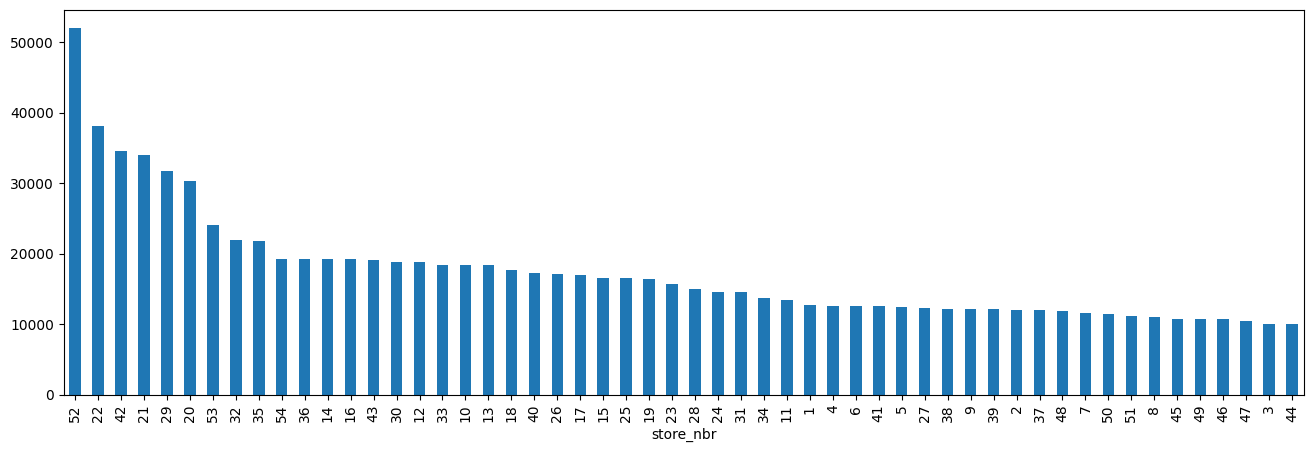

In [31]:
zero_sales_family_distribution.groupby('store_nbr')['is_zero'].sum().sort_values(ascending=False).plot.bar(figsize=(16, 5))

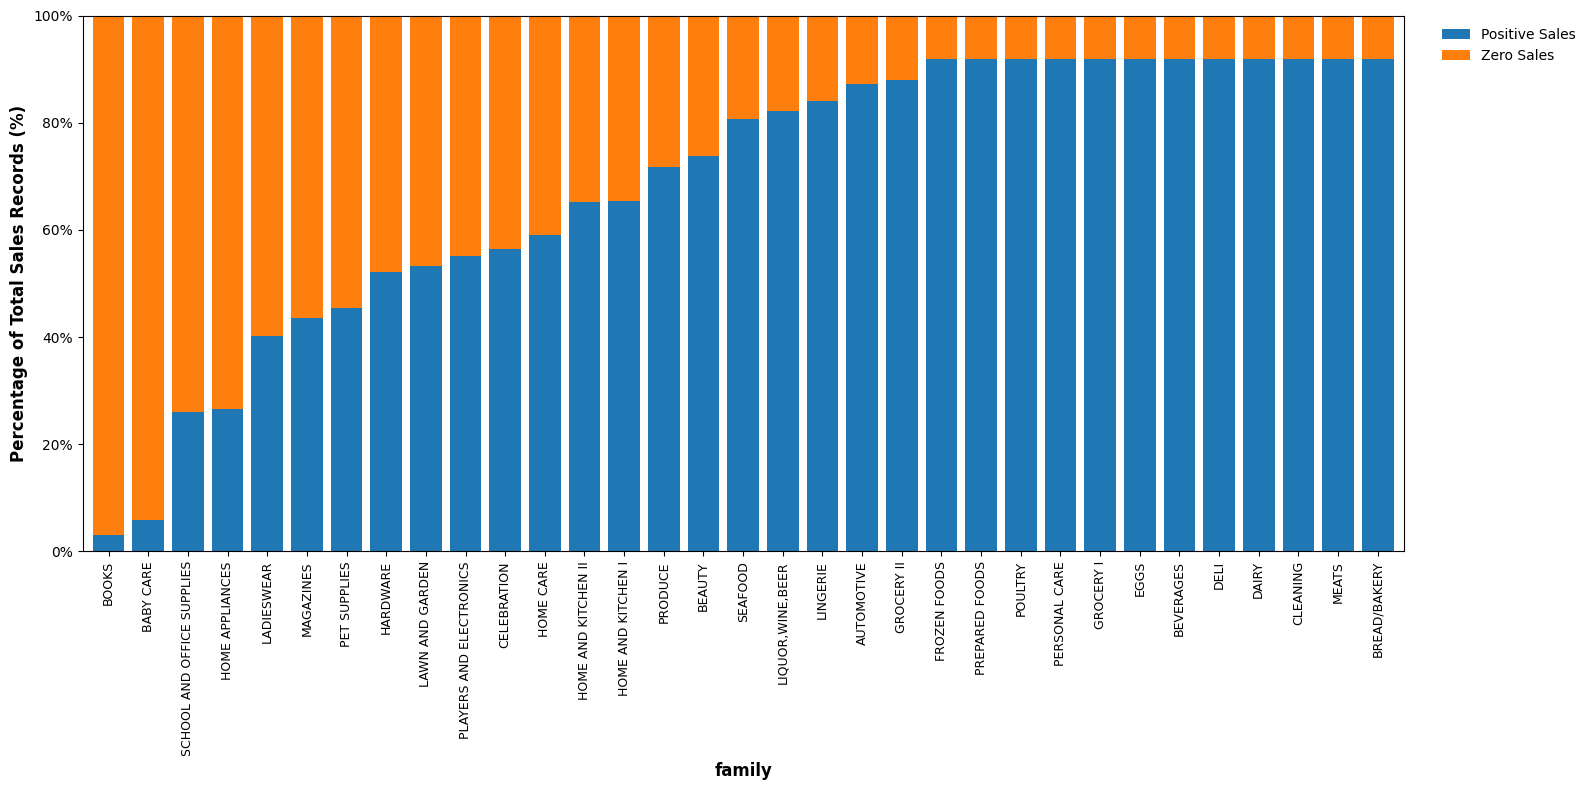

In [32]:
# 1. Group and unstack, then calculate percentages per store
plot_data = (
    zero_sales_store_distribution.groupby(['family', 'sales_status'])
    .size()
    .unstack(fill_value=0)
    .sort_values(by='Zero Sales', ascending=False)
)

# Convert counts to proportions/percentages per store row
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

# 2. Plot as a 100% stacked bar chart
ax = plot_data_pct.plot.bar(
    stacked=True, 
    figsize=(16, 8), 
    width=0.8, 
    edgecolor='none'
)

# 3. Format y-axis as percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
plt.ylim(0, 100)

# 4. Styling
plt.ylabel("Percentage of Total Sales Records (%)", fontsize=12, weight='bold')
plt.xlabel("family", fontsize=12, weight='bold')
plt.xticks(rotation=90, fontsize=9)
plt.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Zero sales Family x Store

In [33]:
zero_by_family_store = train.groupby(['store_nbr', 'family'])['sales'].apply(lambda x: (x == 0).mean())
print(zero_by_family_store.sort_values(ascending=False))

store_nbr  family        
54         BOOKS             1.000000
50         BABY CARE         1.000000
49         BABY CARE         1.000000
47         BABY CARE         1.000000
46         BABY CARE         1.000000
                               ...   
40         BEVERAGES         0.002969
39         PREPARED FOODS    0.002969
           POULTRY           0.002969
           PERSONAL CARE     0.002969
           MEATS             0.002969
Name: sales, Length: 1782, dtype: float64


Text(0.5, 0.98, 'Hierarchical Clustering of Zero-Sales Days (Store vs. Family)')

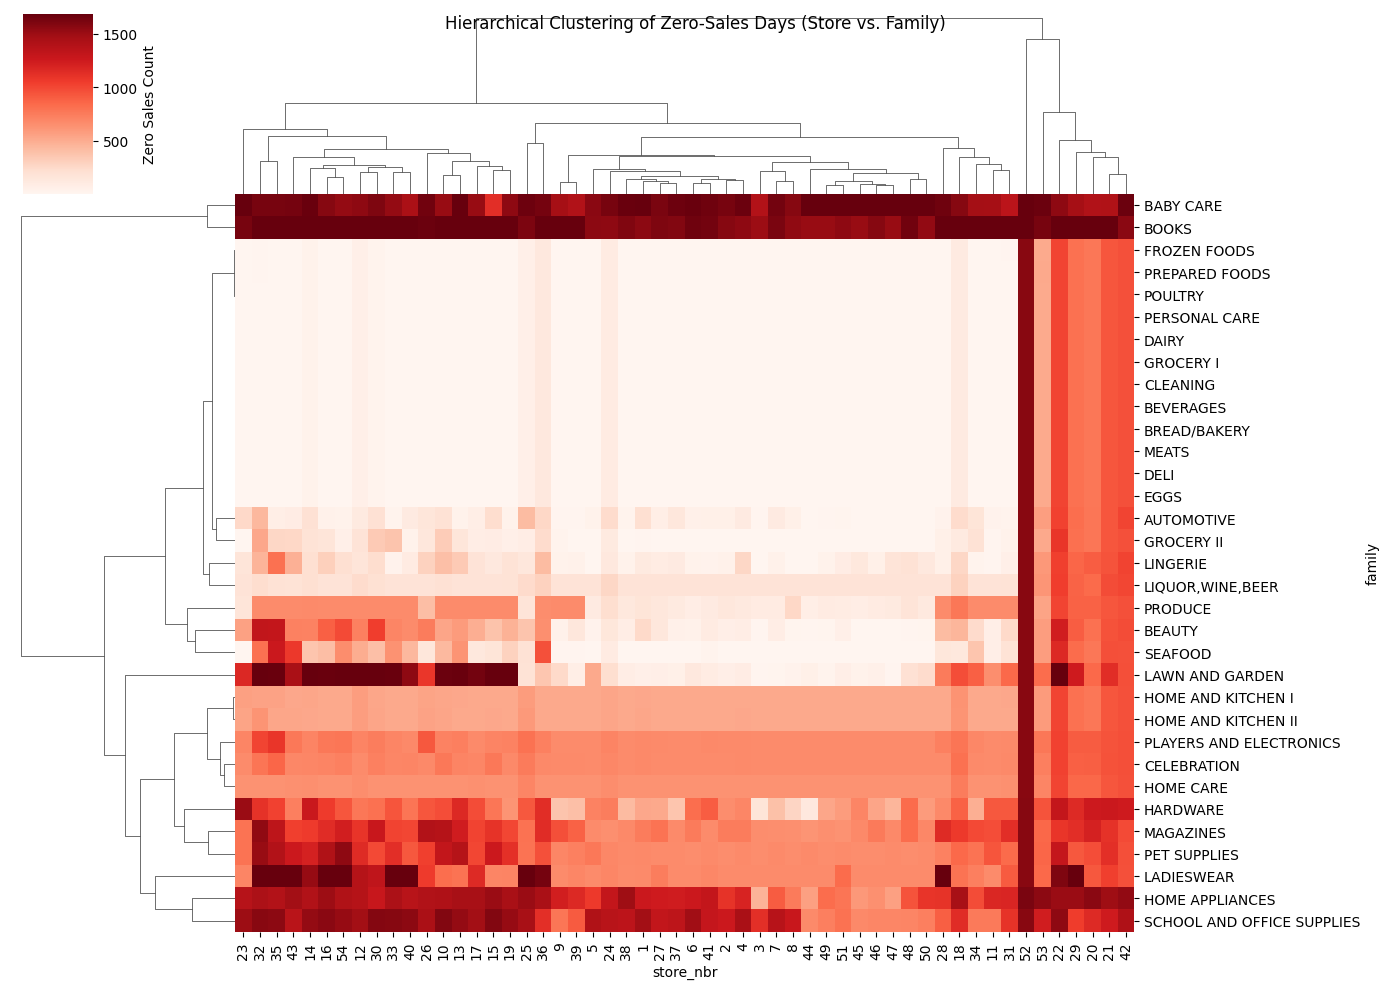

In [34]:
zero_sales_matrix = (
    train.assign(is_zero=(train['sales'] == 0).astype(int))
    .pivot_table(index='family', columns='store_nbr', values='is_zero', aggfunc='sum', fill_value=0)
)

g = sns.clustermap(
    zero_sales_matrix,
    cmap='Reds',
    figsize=(14,10),
    cbar_kws={'label': 'Zero Sales Count'},
    xticklabels=True,
    yticklabels=True
)

g.fig.suptitle("Hierarchical Clustering of Zero-Sales Days (Store vs. Family)")



In [35]:
import dash_bio as dashbio

fig = dashbio.Clustergram(
    data=zero_sales_matrix.values,
    row_labels=list(zero_sales_matrix.index.astype(str)),
    column_labels=list(zero_sales_matrix.columns.astype(str)),
    color_map='Reds',
    height=800,
    width=1200,
    cluster='all'  # Clusters both rows and columns
)

fig.show()

# Zero-sales distribution by day of week

In [36]:
zeros_by_dow = train.groupby(train['date'].dt.dayofweek)['sales'].apply(lambda x: (x == 0).mean())
print(zeros_by_dow.sort_values(ascending=False))

date
6    0.320064
3    0.317050
4    0.316353
2    0.315025
1    0.314676
0    0.310172
5    0.297377
Name: sales, dtype: float64


In [37]:
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
zero_sales_day_of_week_distribution = train.assign(day_of_week=train['date'].dt.day_name(), is_zero=train['sales'] ==0).groupby(['day_of_week', 'is_zero']).size().unstack().reindex(ordered_days)

In [38]:
zero_sales_day_of_week_distribution

is_zero,False,True
day_of_week,,
Monday,296255,133207
Tuesday,295542,135702
Wednesday,292950,134730
Thursday,292084,135596
Friday,292382,135298
Saturday,301750,127712
Sunday,290795,136885


<Axes: xlabel='day_of_week'>

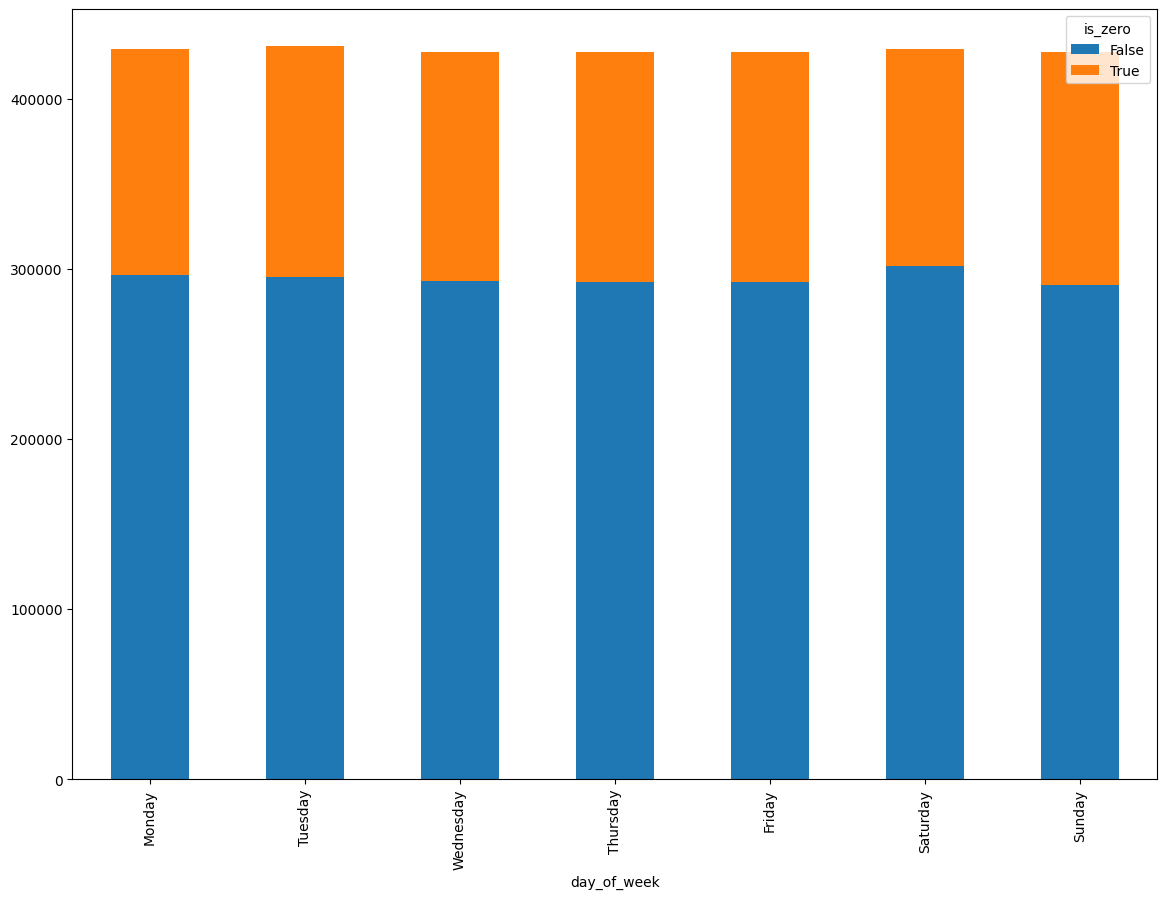

In [40]:
zero_sales_day_of_week_distribution.plot.bar(stacked=True, figsize=(14,10))

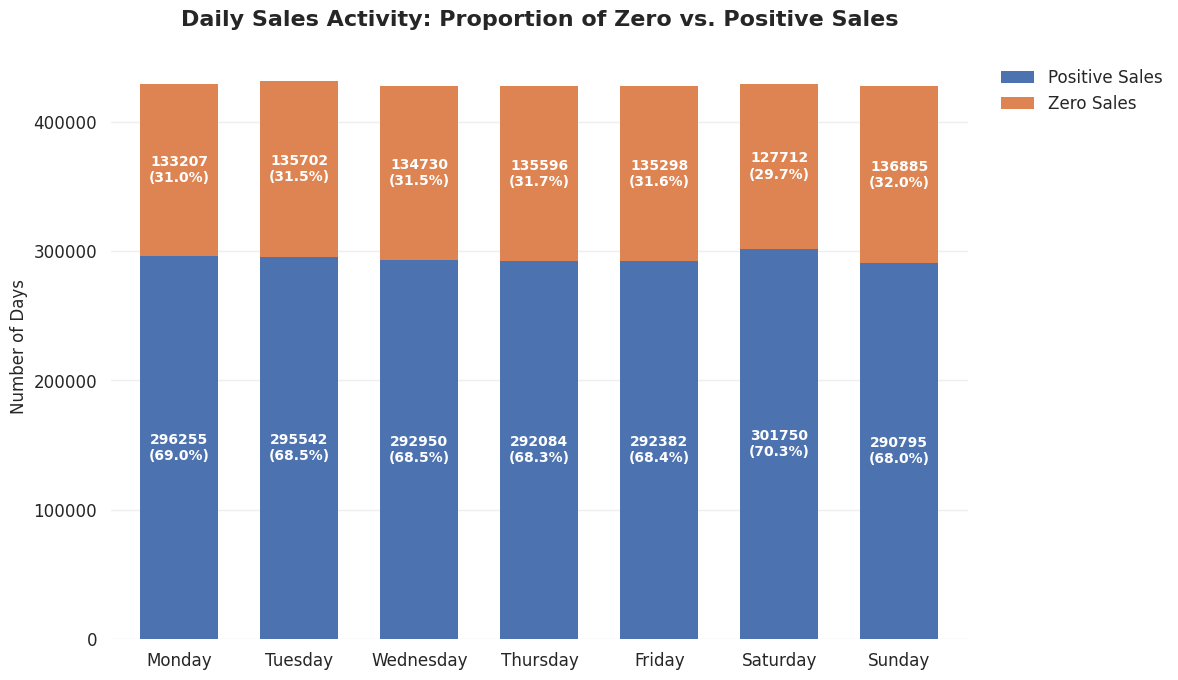

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 1. Prepare data
plot_data = (
    train.assign(
        day_of_week=train['date'].dt.day_name(),
        Sales_Status=np.where(train['sales'] == 0, 'Zero Sales', 'Positive Sales')
    )
    .groupby(['day_of_week', 'Sales_Status'])
    .size()
    .unstack(fill_value=0) # fill_value=0 ensures no NaN errors when calculating %
    .reindex(ordered_days)
)

# 2. Create the base plot
colors = {'Positive Sales': '#4C72B0', 'Zero Sales': '#DD8452'}
ax = plot_data.plot.bar(
    stacked=True, figsize=(12, 7), width=0.65, edgecolor='none',
    color=[colors.get(col, '#333333') for col in plot_data.columns]
)

# 3. Add internal labels with Count and Percentage
daily_totals = plot_data.sum(axis=1) # Total records per day

for container in ax.containers:
    # Calculate percentage for each segment and format the text
    labels = [
        f"{val:g}\n({(val / total) * 100:.1f}%)" if val > 0 else "" 
        for val, total in zip(container.datavalues, daily_totals)
    ]
    ax.bar_label(container, labels=labels, label_type='center', color='white', weight='bold', fontsize=10)

# 4. Polish
plt.title("Daily Sales Activity: Proportion of Zero vs. Positive Sales", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("")
plt.ylabel("Number of Days", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine(left=True, bottom=True)
ax.yaxis.grid(True, color='#EEEEEE')
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

# Detect Sunday Closures

In [ ]:
sunday_zero_rate = train[train["date"].dt.dayofweek == 6].groupby("store_nbr")['sales'].apply(lambda x: (x==0).mean())
sunday_zero_rate.sort_values(ascending=False).head(5)*100

store_nbr
52    93.409091
22    68.270202
42    62.361111
21    60.239899
29    57.032828
Name: sales, dtype: float64

- The only stores that have "sunday closure" are the one who have zero days with sales overall the days and series. 

# Detect true zeros (dead series)


In [43]:
series_zero_rate = train.groupby(['store_nbr', 'family'])["sales"].apply(lambda x: (x == 0).mean()).sort_values(ascending=False)
dead_series = series_zero_rate[series_zero_rate > 0.95]
print(dead_series.shape)
intermittent = series_zero_rate[(series_zero_rate > 0.1) & (series_zero_rate <= 0.95)]
print(intermittent.shape)
low_zero = series_zero_rate[series_zero_rate <= 0.1]
print(low_zero.shape)


(96,)
(931,)
(755,)


In [44]:
# Detect intermittend demand (coefficient of variation of inter-demand invervals)
def demand_regularity(series):
    nonzero_idx = series[series > 0].index
    gaps = np.diff(nonzero_idx)
    if len(gaps) < 2:
        return np.inf
    return gaps.std() / gaps.mean() # CV of inter_demand time


In [45]:
demand_regularity = train.groupby(['store_nbr', 'family'])["sales"].apply(demand_regularity)

In [46]:
demand_regularity.head(5)

store_nbr  family    
1          AUTOMOTIVE    0.403395
           BABY CARE          inf
           BEAUTY        0.421783
           BEVERAGES     0.054360
           BOOKS         0.953272
Name: sales, dtype: float64

# Zero handling strategy

- **Is zero-rate uniform or concetrated in specific series?**
    - 


## Forecasting DataFrame

In [ ]:
df = train[["unique_id", "date", "sales"]].rename(columns={"date": "ds", "sales": "y"})

In [ ]:
df

,unique_id,ds,y
0,store_1_AUTOMOTIVE,2013-01-01,0.000
1,store_1_BABY CARE,2013-01-01,0.000
2,store_1_BEAUTY,2013-01-01,0.000
3,store_1_BEVERAGES,2013-01-01,0.000
4,store_1_BOOKS,2013-01-01,0.000
...,...,...,...
3000883,store_9_POULTRY,2017-08-15,438.133
3000884,store_9_PREPARED FOODS,2017-08-15,154.553
3000885,store_9_PRODUCE,2017-08-15,2419.729
3000886,store_9_SCHOOL AND OFFICE SUPPLIES,2017-08-15,121.000


In [ ]:
zero_pct = (df['y'] == 0).mean()
print(f"Zero sales percentage: {zero_pct:.1%}")

Zero sales percentage: 31.3%


## Time Series Patterns

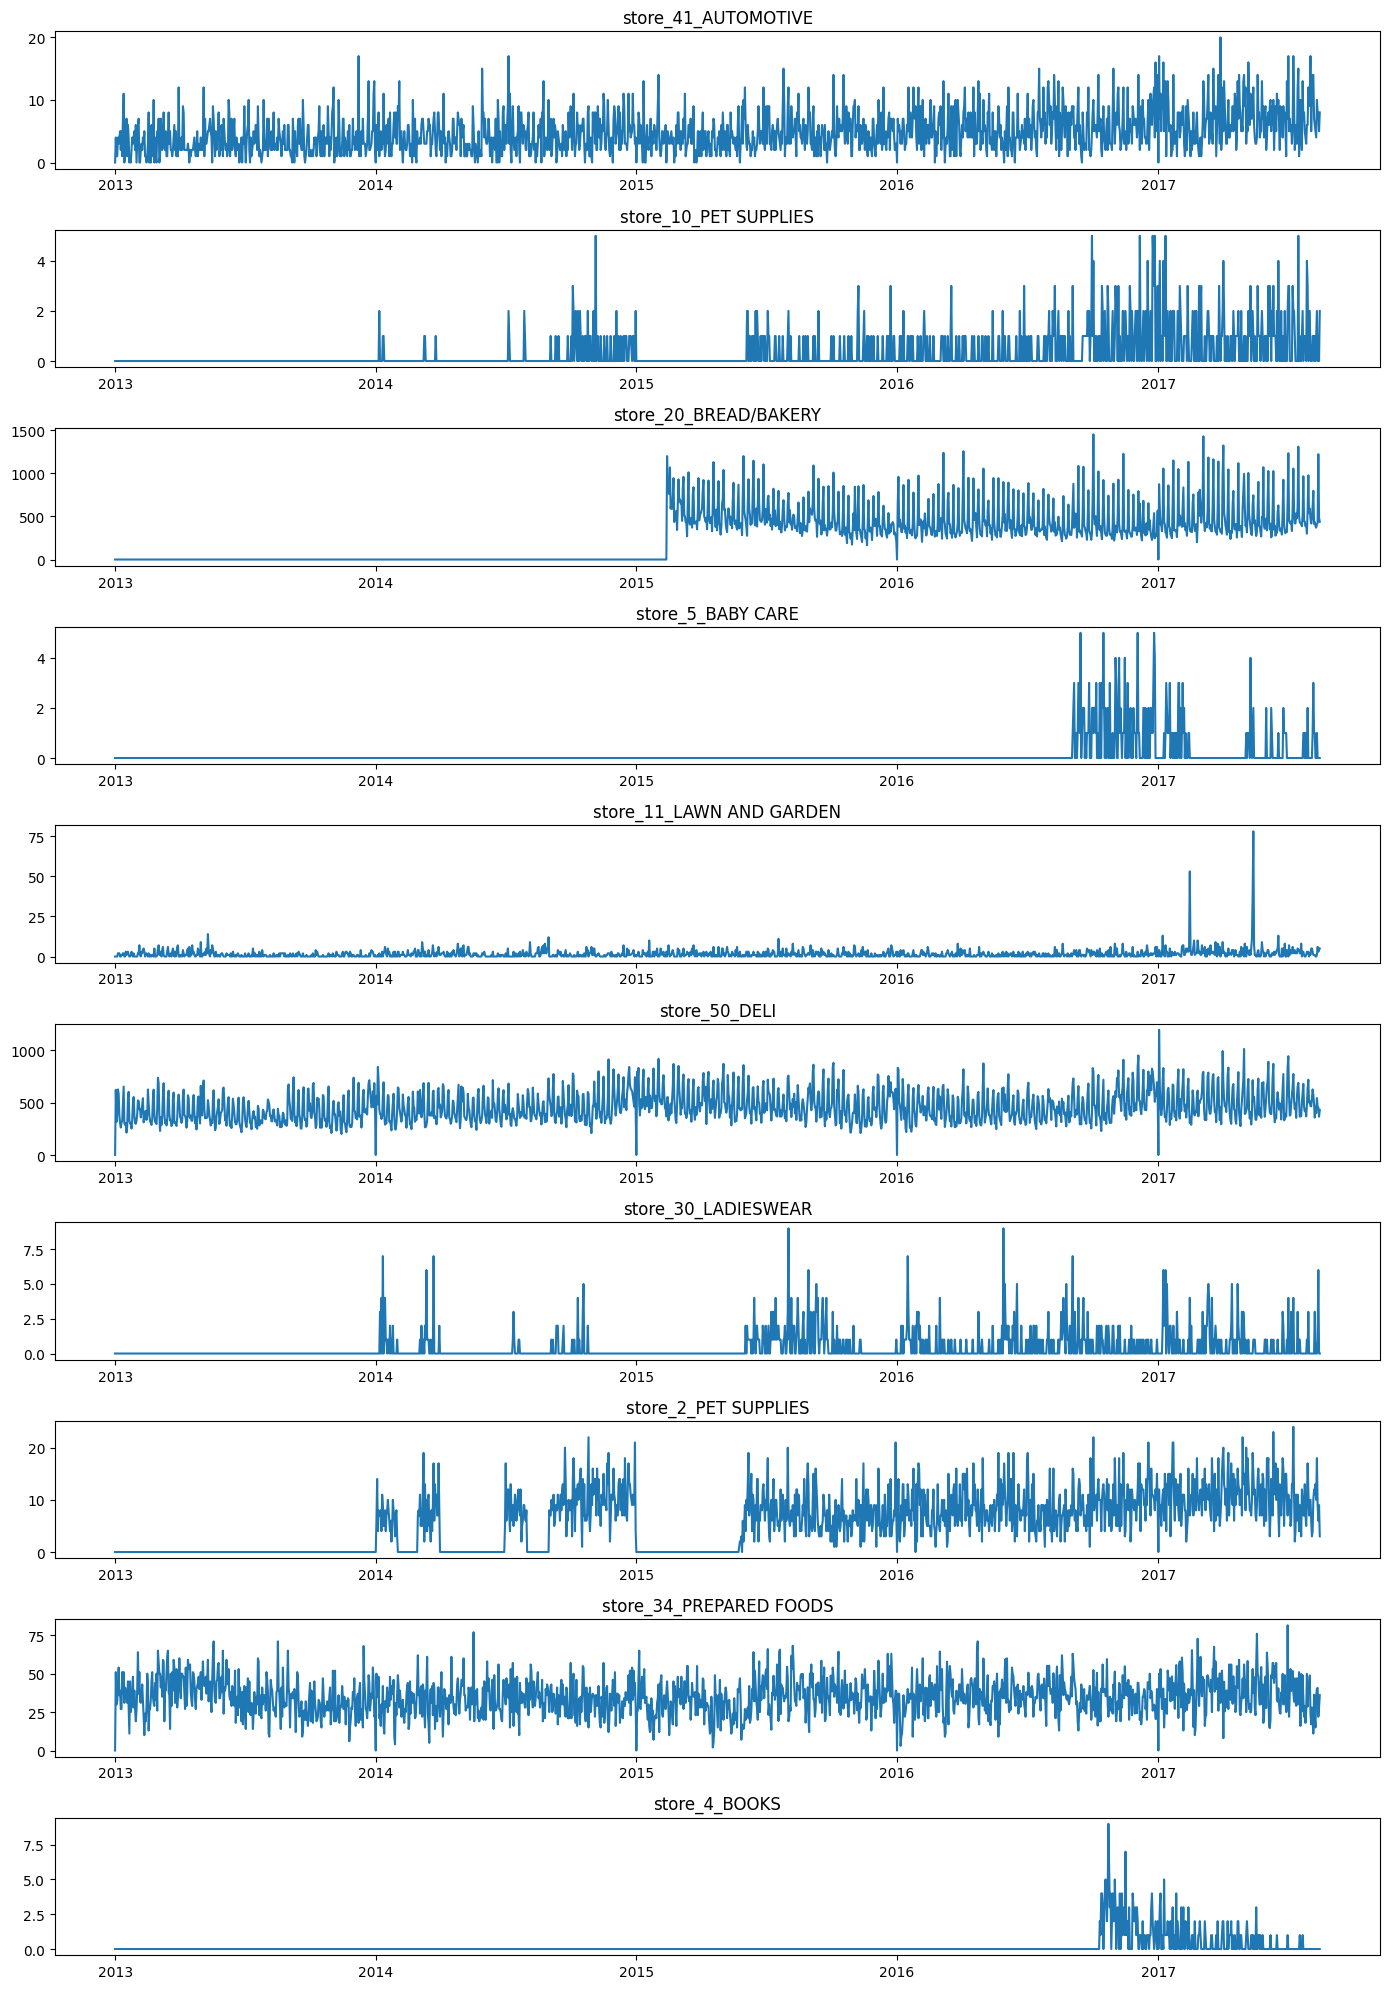

In [ ]:
# Plot a few series to see patterns
fig, axes = plt.subplots(10, 1, figsize=(14, 20))
sample_ids = df['unique_id'].sample(n=10, random_state=1)
for uid, ax in zip(sample_ids, axes):
    subset = df[df['unique_id'] == uid]
    ax.plot(subset['ds'], subset['y'])
    ax.set_title(uid)
plt.tight_layout()
plt.savefig('eda_sample_series.png')
plt.show()

NameError: name 'df' is not defined

# StatsForecast Baseline

## Data Subsetting and Train-Test Split

In [ ]:
print(df['unique_id'].nunique())

In [ ]:
# SUBSET first
subset_categories = ['1_BEVERAGES', '34_PREPARED FOODS', '8_CLEANING', '33_DAIRY', '10_GROCERY I']

In [ ]:
df_sample = df[df['unique_id'].isin(subset_categories)].copy()

In [ ]:
# Split: last 16 days as test (Kaggle uses 16-day horizon)
# df_sample['ds'] = pd.to_datetime(df_sample['ds']).dt.normalize()

max_date_per_series = df_sample.groupby('unique_id', as_index=False)['ds'].transform('max')

cutoff = max_date_per_series - pd.Timedelta(days=16)
train_df = df_sample[df_sample['ds'] <= cutoff]
val_df = df_sample[df_sample['ds'] > cutoff]

In [ ]:
print(train_df['ds'].max(), val_df['ds'].min())

In [ ]:
train_df.shape

In [ ]:
train_df.groupby('unique_id').mean()

In [ ]:
val_df.shape

## Model Training and Forecast

In [ ]:
EVAL_ARTIFACT_NAME = "metrics_per_series.csv"

def evaluate_models(eval_df: pd.DataFrame, model_cols: list) -> pd.DataFrame:
    results = []
    for uid in eval_df['unique_id'].unique():
        mask = eval_df['unique_id'] == uid
        for model in model_cols:
            y_true = eval_df.loc[mask, 'y'].values
            y_pred = eval_df.loc[mask, model].values
            y_pred_clipped = np.clip(y_pred, 0, None)
            val_mae = mean_absolute_error(y_true, y_pred)
            val_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            val_rmsle = root_mean_squared_log_error(y_true, y_pred_clipped)
            results.append({'unique_id': uid, 'model': model, 'MAE': val_mae, 'RMSE': val_rmse, 'RMSLE': val_rmsle})

    return pd.DataFrame(results)

In [ ]:
class ForecastModel(mlflow.pyfunc.PythonModel):
    def __init__(self, model, framework, horizon=16):
        self.model = model
        self.framework = framework
        self.horizon = horizon

    def predict(self, context, model_input, params=None):
        h = params.get("horizon", self.horizon) if params else self.horizon
        if self.framework == "statsforecast":
            return self.model.forecast(df=model_input, h=h)
        else:
            return self.model.predict(df=model_input)


        

In [ ]:
# Define models
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoARIMA,
    AutoETS,
    AutoCES,
    CrostonOptimized, # For intermittent demand
    SeasonalNaive, 
    HistoricAverage
)
from statsforecast.utils import ConformalIntervals # This allow to calculate the Confidence intervals

# Parameters
horizon = 16
season_length = 7
freq = 'D' # Daily data
conf_level = 90
n_windows = 2

intervals = ConformalIntervals(h=horizon, n_windows=n_windows) # TODO: How this works.

models = [
    AutoARIMA(season_length=season_length, prediction_intervals=intervals),
    AutoETS(season_length=season_length, prediction_intervals=intervals),
    AutoCES(season_length=season_length, prediction_intervals=intervals),
    CrostonOptimized(prediction_intervals=intervals), # Intermittent demand
    SeasonalNaive(season_length=season_length, prediction_intervals=intervals), 
    HistoricAverage(prediction_intervals=intervals)
]

model_names = [type(model).__name__ for model in models]

params_to_log = {
    "forecast_horizon": horizon,
    "forecast_conf_level": conf_level,
    "sf_season_length": season_length,
    "sf_models": model_names,
    "sf_freq": freq,
    "interval_type": "Conformal",
    "interval_n_windows": n_windows,
    "random_seed": RANDOM_SEED,
    "statsforecast_version": sf_pkg.__version__,
    "python_version": platform.python_version(),
}

# Feature Set
standard_cols = ['unique_id', 'ds', 'y']


with mlflow.start_run(run_name="statsforecast/baseline/2026-08-26") as run:
    start_time = time.perf_counter()
    # Log dataset metadata
    dataset = mlflow.data.from_pandas(
        train_df, 
        source=f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/train.csv",
        name='training_dataset'
    )

    mlflow.log_input(dataset, context="training")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log)
    print("Parameters logged successfully.")


    # Log feature set
    mlflow.log_dict({"baseline_features": standard_cols}, "feature_sets/features.json")
    print("Feature set logged successfully.")


    # Fit and forecast
    sf = StatsForecast(
        models=models, 
        freq=freq,
        n_jobs=-1, # Parallel
    )



    # Use .forecast() for speed (no fitted values stored)
    forecasts = sf.forecast(df=train_df, h=horizon, level=[conf_level])
    print("Generated StatsForecasts.")

    sf.save(path="statsforecast_models")
    mlflow.log_artifacts("statsforecast_models", 
                         artifact_path = "statsforecast_models")

    # with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp_file:
    #     joblib.dump(sf, tmp_file.name)
    #     mlflow.log_artifact(tmp_file.name, "model")
    #     print(f"StatsForecast model saved and logged to MLflow at {tmp_file.name}")

    mlflow.pyfunc.log_model(
        artifact_path="model",
        python_model=ForecastModel(sf, "statsforecast", horizon=horizon),
        pip_requirements=["statsforecast", "pandas", "numpy"]
    )

    end_time = time.perf_counter()
    run_time = end_time - start_time
    mlflow.log_metric("training_time_in_seconds", run_time)


    # Evaluate
    eval_df = val_df.merge(forecasts.reset_index(), on=['unique_id', 'ds'])
    model_cols = [c for c in forecasts.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]
    result_df = evaluate_models(eval_df=eval_df, model_cols=model_cols)

    # Log per-unique_id metrics
    result_df.to_csv(EVAL_ARTIFACT_NAME, index=False)
    mlflow.log_artifact(EVAL_ARTIFACT_NAME, "evaluation")

    # Log aggregated metrics
    mlflow.log_metric("mean_MAE", result_df['MAE'].mean())
    mlflow.log_metric("mean_RMSE", result_df['RMSE'].mean())
    mlflow.log_metric("mean_RMSLE", result_df['RMSLE'].mean())


    print("Evaluation metrics logged successfully.")


    print(f"Run completed. Run ID: {run.info.run_id}, Experiment ID: {run.info.experiment_id}")

In [ ]:
print(forecasts.head(6))

## Evaluation

In [ ]:
val_df.columns

In [ ]:
# Evaluation
eval_df = val_df.merge(forecasts.reset_index(), on=['unique_id', 'ds'])
model_cols = [c for c in forecasts.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]

In [ ]:
model_cols

In [ ]:
# Evaluate each model for each series
mask = eval_df['unique_id'] == '8_CLEANING'
print(mean_absolute_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, 'AutoARIMA']))

In [ ]:

def print_evaluation_results(results_df: pd.DataFrame):
    print("\n=== Model Comparison ===")
    print(results_df.pivot_table(index='model', values=['MAE', 'RMSE', 'RMSLE'], aggfunc='mean').round(2))

    best_mae = results_df.loc[results_df.groupby('unique_id')['MAE'].idxmin()]
    print("\n=== Best Model per Series (MAE) ===")
    print(best_mae[['unique_id', 'model', 'MAE']])

    best_rmse = results_df.loc[results_df.groupby('unique_id')['RMSE'].idxmin()]
    print("\n=== Best Model per Series (RMSE) ===")
    print(best_rmse[['unique_id', 'model', 'RMSE']])

    best_rmsle = results_df.loc[results_df.groupby('unique_id')['RMSLE'].idxmin()]
    print("\n=== Best Model per Series (RMSLE) ===")
    print(best_rmsle[['unique_id', 'model', 'RMSLE']])

In [ ]:
results_df = evaluate_models(eval_df, model_cols)
print_evaluation_results(results_df)

## Cross-Validation

In [ ]:
# StatForecast has built-in time series cross-validation

# Parameteers for cross-validation
horizon = 16
step_size = 16
n_windows = 3
conf_level = 90

params_to_log_cv = {
    "forecast_horizon": horizon,
    "sf_models": model_names,
    "sf_freq": "D",
    "step_size": step_size,
    "conf_level": conf_level,
    "interval_n_windows": n_windows,
    "random_seed": RANDOM_SEED,
    "statsforecast_version": sf_pkg.__version__,
    "python_version": platform.python_version(),
}

# Feature Set
standard_cols = ['unique_id', 'ds', 'y']

with mlflow.start_run(run_name="statsforecast/crossval_baseline/2026-08-26") as run:

    # Log dataset metadata
    dataset = mlflow.data.from_pandas(
        df_sample, 
        source=f"/home/{os.getenv('USER')}/.cache/kaggle/competitions/{competition_name}/train.csv",
        name='crossval_dataset_baseline'
    )

    mlflow.log_input(dataset, context="crossval")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log_cv)
    print("Parameters logged successfully.")


    # Log feature set
    mlflow.log_dict({"baseline_features": standard_cols}, "feature_sets/baseline_features.json")
    print("Feature set logged successfully.")
    
    crossval = sf.cross_validation(
        df=df_sample,
        h=horizon,  # Forecast horizon 
        step_size=step_size, # Non-overlapping windows
        n_windows=n_windows, # 3 folds
        level=[conf_level], # Confidence intervals
    )

    print("Cross-validation completed successfully.")

    all_folds_metrics = []
    all_uid_metrics = []

    # Log cross-validation metrics per fold
    for fold_idx, (cutoff, fold_df) in enumerate(crossval.groupby('cutoff')):
        result = evaluate(fold_df.drop(columns=['cutoff']),
                          metrics=[mae, rmse, rmsle]
        )

        # Aggregate by model 
        mean_metrics = result.drop(columns=['unique_id']).groupby('metric').mean()

        fold_dict = {}

        for metric_name, row in mean_metrics.iterrows():
            for model_name, value in row.items():
                key = f"{model_name}_{metric_name}"
                fold_dict[key] = value
                
        mlflow.log_metrics(fold_dict, step=fold_idx)
        all_folds_metrics.append(fold_dict)

        # per-unique_id metrics
        result_wide = result.pivot_table(
            index='unique_id', 
            columns='metric', 
            values=result.columns.difference(['unique_id', 'metric'])
        ).reset_index()
        result_wide['fold'] = fold_idx
        all_uid_metrics.append(result_wide)

    # Log per-uid metrics
    uid_metrics_df = pd.concat(all_uid_metrics)
    uid_metrics_df.to_csv(EVAL_ARTIFACT_NAME, index=False)
    mlflow.log_artifact(EVAL_ARTIFACT_NAME, "evaluation")


    # Aggregate fold results
    cv_results_df = pd.DataFrame(all_folds_metrics)
    aggregated_metrics = {}
    for model in cv_results_df.columns:
        aggregated_metrics[f"{model}_cv_mean"]= cv_results_df[model].mean()
        aggregated_metrics[f"{model}_cv_std"] = cv_results_df[model].std()

    mlflow.log_metrics(aggregated_metrics)

    print("Logged individual fold metrics and aggregated totals of the CV.")
    print(crossval.head())

In [ ]:
print("\n=== MAE ===")
for model in model_cols:
    val_mae = mean_absolute_error(crossval['y'], crossval[model])
    print(f"{model}: CV MAE = {val_mae:.2f}")

print("\n=== RMSE ===")
for model in model_cols:
    val_rmse = np.sqrt(mean_squared_error(crossval['y'], crossval[model]))
    print(f"{model}: CV RMSE = {val_rmse:.2f}")

print("\n=== RMSLE ===")
for model in model_cols:
    val_rmsle = root_mean_squared_log_error(crossval['y'], crossval[model])
    print(f"{model}: CV RMSLE = {val_rmsle:.2f}")


## Forecast Visualization

In [ ]:
# Plot forecasts vs actual for 2-3 series
fig, axes = plt.subplots(len(subset_categories[:3]), 1, figsize=(14,10))
for ax, uid in zip(axes, subset_categories[:3]):
    # Historical
    hist = train_df[train_df['unique_id'] == uid].tail(60)
    ax.plot(hist['ds'], hist['y'], label='Historical', color='black')

    # Actuals in validation period
    actual = val_df[val_df['unique_id'] == uid]
    actual = pd.concat([train_df[train_df['unique_id'] == uid].tail(1), actual])
    ax.plot(actual['ds'], actual['y'], label='Actual', color='green', linewidth=2)

    # Forecast (best 2 models)
    fc = forecasts.reset_index()
    fc_uid = fc[fc['unique_id'] == uid]
    ax.plot(fc_uid['ds'], fc_uid['AutoARIMA'], label='AutoARIMA', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['AutoETS'], label='AutoETS', linestyle='--')

    # Confidence interval
    if 'AutoARIMA-lo-90' in fc_uid.columns:
        ax.fill_between(fc_uid['ds'], fc_uid['AutoARIMA-lo-90'],
                        fc_uid['AutoARIMA-hi-90'], alpha=0.2)
    ax.set_title(uid)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()

# Stretch Goals (if time allows)

- [x] Add oil.csv as exogenous variable to AutoARIMA
- [x] Try NeuralForecast: NHITS, PatchTST on same data
- [x] Add MLflow tracking for experiment logging
- [ ] Hierarchical forecasting: store-level → family-level reconciliation

# Exogenous Variables: Oil Price

## Data Loading

In [ ]:
oil_df = pd.read_csv(path + '/oil.csv', parse_dates=['date'])

In [ ]:
print(f"{oil_df.head(5)}", f"\n {oil_df.tail(5)}")

## Missing Values

In [ ]:
oil_df.isna().sum()

In [ ]:
oil_df = oil_df.set_index('date').asfreq('D').ffill().bfill().reset_index()


In [ ]:
oil_df.isna().sum()

In [ ]:
oil_df = oil_df.rename(columns={'dcoilwtico': 'oil_price'})

## Merge with Training and Test Data

In [ ]:
exo_train_df = train_df.copy().merge(oil_df, right_on='date', left_on='ds', how='left').drop(columns='date')

In [ ]:
exo_train_df.isna().sum()

In [ ]:
exo_val_df = val_df.copy().merge(oil_df, right_on='date', left_on='ds', how='left').drop(columns='date')

In [ ]:
exo_val_df.isna().sum()

In [ ]:
exo_val_df[exo_val_df['oil_price'].isna()]

In [ ]:
exo_train_df.isna().sum()

In [ ]:
print(exo_val_df.shape, val_df.shape)
print(exo_val_df.columns)

## Model Training and Forecast

In [ ]:

# Parameters
horizon = 16
season_length = 7
freq = 'D' # Daily data
conf_level = 90
n_windows = 2

intervals = ConformalIntervals(h=horizon, n_windows=n_windows) # TODO: How this works.

models = [
    AutoARIMA(season_length=season_length, prediction_intervals=intervals),
    AutoETS(season_length=season_length, prediction_intervals=intervals),
    AutoCES(season_length=season_length, prediction_intervals=intervals),
    CrostonOptimized(prediction_intervals=intervals), # Intermittent demand
    SeasonalNaive(season_length=season_length, prediction_intervals=intervals), 
    HistoricAverage(prediction_intervals=intervals)
]

model_names = [type(model).__name__ for model in models]

params_to_log = {
    "forecast_horizon": horizon,
    "forecast_conf_level": conf_level,
    "sf_season_length": season_length,
    "sf_models": model_names,
    "sf_freq": freq,
    "interval_type": "Conformal",
    "interval_n_windows": n_windows,
    "random_seed": RANDOM_SEED,
    "statsforecast_version": sf_pkg.__version__,
    "python_version": platform.python_version(),
} 

sources = [
    f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/train.csv",
    f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/oil.csv"
]

combined_sources= "|".join(sources)

# Feature Set
standard_cols = ['unique_id', 'ds', 'y']
exogenous_features = [col for col in exo_train_df.columns if col not in standard_cols]


with mlflow.start_run(run_name="statsforecast/baseline+oil/2026-08-27") as run:

    # Log dataset metadata
    dataset = mlflow.data.from_pandas(
        exo_train_df,
        source=combined_sources,
        name='training_dataset_with_oil_exogenous'
    )
    mlflow.log_input(dataset, context="training_with_oil_exogenous")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log)
    print("Logged parameters successfully.")


    # Log feature set
    mlflow.log_dict({"baseline_features": standard_cols, "exogenous_features": exogenous_features}, "feature_sets/features.json")
    print(f"Logged {len(exogenous_features)} exogenous features artifacts")
    print(f"Feature set logged successfully.")

    # Fit and forecast
    sf = StatsForecast(
        models=models,
        freq=freq, # Daily data
        n_jobs=-1, # Parallel
    )


    # Use .forecast() for speed (no fitted values stored)
    forecasts = sf.forecast(
        df=exo_train_df,
        h=horizon,
        level=[conf_level], 
        X_df=exo_val_df[['unique_id', 'ds', 'oil_price']],
    )

    print("Generated forecasts with exogenous variable (oil price).")

    mlflow.pyfunc.log_model(
        artifact_path="model",
        python_model=ForecastModel(sf, "statsforecast", horizon=horizon),
        pip_requirements=["statsforecast", "pandas", "numpy"]
    )

    eval_df = exo_val_df.merge(forecasts.reset_index(), on=['unique_id', 'ds'])
    model_cols = [c for c in forecasts.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]
    results_df = evaluate_models(eval_df=eval_df, model_cols=model_cols)

    # Log per-unique_id metrics
    results_df.to_csv(EVAL_ARTIFACT_NAME, index=False)
    mlflow.log_artifact(EVAL_ARTIFACT_NAME, "evaluation")

    # Log aggregated metrics
    mlflow.log_metric("mean_MAE", results_df['MAE'].mean())
    mlflow.log_metric("mean_RMSE", results_df['RMSE'].mean())
    mlflow.log_metric("mean_RMSLE", results_df['RMSLE'].mean())

    print("Evaluation metrics logged successfully.") 

    print(f"Run completed. Run ID: {run.info.run_id}, Experiment ID: {run.info.experiment_id}")

## Evaluation

In [ ]:
eval_df

In [ ]:
# Test evaluation for a specific series
mask = eval_df['unique_id'] == '8_CLEANING'
print(mean_absolute_error(eval_df.loc[mask, 'y'], eval_df.loc[mask, 'AutoARIMA']))

In [ ]:
print_evaluation_results(results_df)

## Cross-Validation with Exogenous Variables

In [ ]:
df_oil = df_sample.merge(oil_df, how='left', left_on='ds', right_on='date')

In [ ]:
df_oil = df_oil.drop(columns=['date'])

In [ ]:
# df_oil['oil_price'] = df_oil['oil_price'].ffill().bfill()

In [ ]:
# StatForecast has built-in time series cross-validation
horizon = 16
step_size = 16
n_windows = 3
conf_level = 90

params_to_log_cv = {
    "forecast_horizon": horizon,
    "sf_models": model_names,
    "sf_freq": "D",
    "step_size": step_size,
    "conf_level": conf_level,
    "interval_n_windows": n_windows,
    "random_seed": RANDOM_SEED,
    "statsforecast_version": sf_pkg.__version__,
    "python_version": platform.python_version(),
}

# Feature Set
standard_cols = ['unique_id', 'ds', 'y']
cols_to_log = standard_cols + ['oil_price']

sources = [
    f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/train.csv",
    f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/oil.csv"
]   

source = "|".join(sources)


with mlflow.start_run(run_name="statsforecast/crossval_oil/2026-09-10") as run:

    # Log dataset metadata
    mlflow.log_input(mlflow.data.from_pandas(df_oil, source=source, name='crossval_dataset_with_oil_exogenous'), context="crossval_with_oil_exogenous")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log_cv)
    print("Logged architecture parameters successfully.")

    # Log Feature set
    mlflow.log_dict({"baseline_features": standard_cols, "exogenous_features": ['oil_price']}, "feature_sets/features.json")
    print("Feature set logged successfully.")    


    crossval_exogen = sf.cross_validation(
        df=df_oil,
        h=horizon,
        step_size=step_size, # Non-overlapping windows
        n_windows=n_windows, # 3 folds
        level=[conf_level],
    )
    print("Cross-validation completed successfully.")


    all_folds_metrics = []
    all_uid_metrics = []

    # Log cross-validation metrics per fold
    for fold_idx, (cutoff, fold_df) in enumerate(crossval_exogen.groupby('cutoff')):
        result = evaluate(fold_df.drop(columns=['cutoff']),
                          metrics=[mae, rmse, rmsle])

        # Aggregate by model
        mean_metrics = result.drop(columns=['unique_id']).groupby('metric').mean()

        fold_dict = {}

        for metric_name, row in mean_metrics.iterrows():
            for model_name, value in row.items():
                key = f"{model_name}_{metric_name}"
                fold_dict[key] = value

        mlflow.log_metrics(fold_dict, step=fold_idx)
        all_folds_metrics.append(fold_dict)

        # per-unique_id metrics
        result_wide = result.pivot_table(
            index='unique_id',
            columns='metric',
            values=result.columns.difference(['unique_id', 'metric'])
        ).reset_index()
        result_wide['fold'] = fold_idx
        all_uid_metrics.append(result_wide)

    # Log per-uid metrics
    uid_metrics_df = pd.concat(all_uid_metrics)
    uid_metrics_df.to_csv(EVAL_ARTIFACT_NAME, index=False)
    mlflow.log_artifact(EVAL_ARTIFACT_NAME, "evaluation")


    # Aggregate fold results
    cv_results_df = pd.DataFrame(all_folds_metrics)
    aggregated_metrics = {}
    for model in cv_results_df.columns:
        aggregated_metrics[f"{model}_cv_mean"]= cv_results_df[model].mean()
        aggregated_metrics[f"{model}_cv_std"] = cv_results_df[model].std()  
    

    mlflow.log_metrics(aggregated_metrics)

    print("Logged individual fold metrics and aggregated totals of the CV.")
    print(crossval_exogen.head())

In [ ]:
model_cols = [c for c in forecasts.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]

In [ ]:
print("\n=== RMSLE ===")
for model in model_cols:
    cv_rmsle = root_mean_squared_log_error(crossval_exogen["y"], crossval_exogen[model])
    print(f"{model}: CV RMSLE: {cv_rmsle:.2f}")

print("\n=== MAE ===")

for model in model_cols:
    cv_mae = mean_absolute_error(crossval_exogen['y'], crossval_exogen[model])
    print(f"{model}: CV MAE: {cv_mae:.2f}")

print("\n=== RMSE ===")

for model in model_cols:
    cv_rmse = np.sqrt(mean_squared_error(crossval_exogen['y'], crossval_exogen[model]))
    print(f"{model}: CV RMSE: {cv_rmse:.2f}")


## Visualization

In [ ]:
fig, axes = plt.subplots(len(subset_categories[:3]), 1, figsize=(14,10))

for ax, uid in zip(axes, subset_categories[:3]):

    # Historical
    hist = exo_train_df[exo_train_df['unique_id'] == uid].tail(60)
    ax2 = ax.twinx()
    ax2.plot(hist['ds'], hist['oil_price'], label='Oil Price', color='black')
    ax.plot(hist['ds'], hist['y'], label='Historical', color='gold')


    # Actual in test period
    actual = exo_val_df[exo_val_df['unique_id'] == uid]
    ax.plot(actual['ds'], actual['y'], label='Actual',  color='green', linewidth=2)
    ax2.plot(actual['ds'], actual['oil_price'], label='Oil_price',  color='black', linewidth=2)
    
    
    ax.set_title(uid)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('forecast_with_oil_price_comparison.png', dpi=150)
plt.show()
    

# NeuralForecast

## Setup

In [ ]:
import logging
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, GRU, RNN, NHITS, PatchTST
from neuralforecast.utils import PredictionIntervals

In [ ]:
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)

## Model Training

In [ ]:
%%capture

import torch
import neuralforecast as nf_pkg

# Paramaters
horizon = 16
input_size = 2 * horizon # Input size for the neural network
freq = 'D' # Daily data
max_steps = 500
encoder_hidden_size = 64 # Number of cells in the encoder in LSTM, GRU, RNN
decoder_hidden_size = 64 # MLP number of neurons in each layer
scaler_type = 'standard' # StandardScaler or MinMaxScaler
n_windows = 2 # Number of windows for conformal intervals
intervals = PredictionIntervals(n_windows=n_windows, method="conformal_distribution") # TODO: How this works.

models = [
    LSTM(input_size=input_size,
         h=horizon,
         max_steps=max_steps,
         scaler_type=scaler_type,
         encoder_hidden_size=encoder_hidden_size,
         decoder_hidden_size=decoder_hidden_size,
        ),
    
    GRU(input_size=input_size,
         h=horizon,
         max_steps=max_steps,
         scaler_type=scaler_type,
         encoder_hidden_size=encoder_hidden_size,
         decoder_hidden_size=decoder_hidden_size,
        ),
    RNN(input_size=input_size,
         h=horizon,
         max_steps=max_steps,
         scaler_type=scaler_type,
         encoder_hidden_size=encoder_hidden_size,
         decoder_hidden_size=decoder_hidden_size,
        ),
    NHITS(input_size=input_size,
          h=horizon,
          max_steps=max_steps,
          scaler_type=scaler_type,
    ),
    PatchTST(input_size=input_size,
          h=horizon,
          max_steps=max_steps,
          scaler_type=scaler_type,
    ),  
    
]

model_names = [type(model).__name__ for model in models]

params_to_log = {
    "nf_horizon": horizon,
    "nf_input_size": input_size,
    "nf_max_steps": max_steps,
    "nf_models": model_names,
    "nf_encoder_hidden_size": encoder_hidden_size,
    "nf_decoder_hidden_size": decoder_hidden_size,
    "nf_scaler_type": scaler_type,
    "interval_type": "Conformal",
    "interval_n_windows": n_windows,
    "random_seed": RANDOM_SEED,
    "neuralforecast_version": nf_pkg.__version__,
    "torch_version": torch.__version__,
    "python_version": platform.python_version(),
}


standard_cols = ['unique_id', 'ds', 'y']
exogenous_features = [col for col in train_df.columns if col not in standard_cols]


with mlflow.start_run(run_name="neuralforecast/baseline_train/2026-08-27") as run:
    
    # Log dataset metadata 
    dataset = mlflow.data.from_pandas(
        train_df,
        source=f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/train.csv",
        name='training_dataset'
    )
    mlflow.log_input(dataset, context="training")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log)
    print("Parameters logged successfully.")

    # Log feature set
    mlflow.log_dict({"baseline_features": standard_cols, "exogenous_features": exogenous_features}, "feature_sets/features.json")
    print(f"Logged {len(exogenous_features)} exogenous features artifacts")
    print(f"Feature set logged successfully.")

    nf = NeuralForecast(models=models, freq=freq)

    start_time = time.perf_counter()
    nf.fit(df=train_df, prediction_intervals=intervals)

    end_time = time.perf_counter()
    print(f"Model fitting time: {end_time - start_time:.2f} seconds")
    mlflow.log_metric("training_time_in_seconds", end_time - start_time)

    
    mlflow.pyfunc.log_model(
        artifact_path="model",
        python_model=ForecastModel(nf, "neuralforecast", horizon=horizon),
        pip_requirements=["neuralforecast", "pandas", "numpy", "torch"]
    )

    print("NeuralForecast model logged to MLflow as pyfunc")


    print("NeuralForecast models fitted successfully.")

## Prediction and Evaluation

In [ ]:
with mlflow.start_run(run_name="neuralforecast/baseline_test/2026-09-10") as run:
    
    # Log dataset metadata 
    dataset = mlflow.data.from_pandas(
        val_df,
        source=f"/home/{os.getenv('USER')}/.cache/kagglehub/competitions/{competition_name}/train.csv",
        name='validation_dataset'
    )
    mlflow.log_input(dataset, context="validation")
    print("Dataset metadata logged successfully.")

    # Log architecture parameters
    mlflow.log_params(params_to_log)
    print("Parameters logged successfully.")

    # Log feature set
    mlflow.log_dict({"baseline_features": standard_cols, "exogenous_features": exogenous_features}, "feature_sets/features.json")
    print(f"Logged {len(exogenous_features)} exogenous features artifacts")
    print(f"Feature set logged successfully.")

    start_time = time.perf_counter()
    
    y_hat = nf.predict()

    end_time = time.perf_counter()
    print(f"Inference time: {end_time - start_time:.2f} seconds")

    eval_df = val_df.merge(y_hat.reset_index(), on=['unique_id', 'ds'])
    model_cols = [c for c in y_hat.columns if not c in ['unique_id', 'ds'] and 'lo' not in c and 'hi' not in c]
    results_df = evaluate_models(eval_df, model_cols)

    # Log per-unique_id metrics
    results_df.to_csv(EVAL_ARTIFACT_NAME, index=False)
    mlflow.log_artifact(EVAL_ARTIFACT_NAME, "evaluation")

    # Log aggregated metrics
    mlflow.log_metric("mean_MAE", results_df['MAE'].mean())
    mlflow.log_metric("mean_RMSE", results_df['RMSE'].mean())
    mlflow.log_metric("mean_RMSLE", results_df['RMSLE'].mean())

    print("Evaluation metrics logged successfully.")
    print(f"Run completed. Run ID: {run.info.run_id}, Experiment ID: {run.info.experiment_id}")

In [ ]:
y_hat.head(10)

In [ ]:

print_evaluation_results(results_df)

In [ ]:
fig, axes = plt.subplots(len(subset_categories[:3]), 1, figsize=(14,10))
for ax, uid in zip(axes, subset_categories[:3]):
    # Historical
    hist = train_df[train_df['unique_id'] == uid].tail(60)
    ax.plot(hist['ds'], hist['y'], label='Historical', color='black')

    # Actuals in test period
    actual = val_df[val_df['unique_id'] == uid]
    ax.plot(actual['ds'], actual['y'], label='Actual', color='green', linewidth=2)

    # Forecast (best 2 models)
    fc = y_hat.reset_index()
    fc_uid = fc[fc['unique_id'] == uid]
    ax.plot(fc_uid['ds'], fc_uid['LSTM'], label='LSTM', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['RNN'], label='RNN', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['GRU'], label='GRU', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['NHITS'], label='NHITS', linestyle='--')
    ax.plot(fc_uid['ds'], fc_uid['PatchTST'], label='PatchTST', linestyle='--')

    # Confidence interval
    if 'AutoARIMA-lo-90' in fc_uid.columns:
        ax.fill_between(fc_uid['ds'], fc_uid['AutoARIMA-lo-90'],
                        fc_uid['AutoARIMA-hi-90'], alpha=0.2)
    ax.set_title(uid)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()

# Obtain the best model per unique_id ranked by RMSLE

In [ ]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name(experiment_name)

if not experiment:
    raise ValueError(f"Experiment '{experiment_name}' not found.")

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="metrics.mean_RMSLE > 0",
)
print(f"Found {len(runs)} runs with evaluation metrics")

dfs = []
for r in runs:
    try:
        path = client.download_artifacts(r.info.run_id, f"evaluation/{EVAL_ARTIFACT_NAME}")
        dfs.append(
            pd.read_csv(path)
            .assign(run_name=r.info.run_name, run_id=r.info.run_id)
        )
    except Exception:
        print(f"Skipping run '{r.info.run_name}' (no evaluation artifact)")

if dfs:
    cross_run_df = pd.concat(dfs, ignore_index=True)
    print(f"Loaded evaluation metrics from {len(dfs)} runs")
else:
    raise RuntimeError("No runs with evaluation artifacts found")


In [ ]:
best_model_per_uid = (
    cross_run_df
    .loc[cross_run_df.groupby('unique_id')['RMSLE'].idxmin()]
    [['unique_id', 'model', 'run_id', 'run_name', 'RMSLE', 'MAE', 'RMSE']]
)

In [ ]:
winning_runs = best_model_per_uid['run_id'].unique()

for run_id in winning_runs:
    run_name = best_model_per_uid[best_model_per_uid['run_id'] == run_id]['run_name'].iloc[0]
    model_name = run_name.replace("/", "_")

    mlflow.register_model(
        model_uri=f"runs:/{run_id}/model", name=model_name,
    )

    print(f"Registered model '{model_name}' from run '{run_id}' with name '{run_name}'")



In [ ]:
best_model_per_uid['model'].value_counts()

In [ ]:
truly_best = cross_run_df.loc[cross_run_df.groupby('unique_id')['RMSLE'].idxmin()]

with mlflow.start_run(run_name="analysis/best_models_per_series") as best_run:
    truly_best.to_csv("best_models_per_series.csv", index=False)
    mlflow.log_artifact("best_models_per_series.csv", "evaluation")
    mlflow.log_metric("num_series", len(truly_best))
    mlflow.log_metric("mean_best_RMSLE", truly_best['RMSLE'].mean())
    print(f"Best models table logged. Run ID: {best_run.info.run_id}")

In [ ]:
best_models_path = client.download_artifacts(best_run.info.run_id, "evaluation/best_models_per_series.csv")
best_models_df = pd.read_csv(best_models_path)
best_models_df.head(6)

In [ ]:
best_features = pd.DataFrame([
    {
        "run_name": r.info.run_name,
        "run_id": r.info.run_id,
        "mean_RMSLE": r.data.metrics.get("mean_RMSLE"),
        "mean_MAE": r.data.metrics.get("mean_MAE"),
        "mean_RMSE": r.data.metrics.get("mean_RMSE"),
    }
    for r in runs
    if r.data.metrics.get("mean_RMSLE") is not None
]).sort_values("mean_RMSLE")

best_features

In [ ]:
client = MlflowClient()
for rm in client.search_registered_models():
    print(rm.name, rm.latest_versions[0].version)



In [ ]:
overall_best_run = best_features.iloc[0]['run_id']
champion_name = ""
for run_id in winning_runs:
    run_name = best_model_per_uid[best_model_per_uid['run_id'] == run_id]['run_name'].iloc[0]
    model_name = run_name.replace("/", "_")

    versions = client.search_model_versions(f"name='{model_name}'")
    latest = sorted(versions, key=lambda v: int(v.version), reverse=True)[0]

    if run_id == overall_best_run:
        client.set_registered_model_alias(model_name, "champion", latest.version)
        champion_name = model_name
        print(f"{model_name} -> champion")

    else:
        client.set_registered_model_alias(model_name, "challenger", latest.version)
        print(f"{model_name} -> challenger")

In [ ]:
champion_model = mlflow.pyfunc.load_model(f"models:/{champion_name}@champion")

for rm in client.search_registered_models():
    for alias in client.get_registered_model_aliases(rm.name):
        print(f"{rm.name} v{alias.version} -> @{alias.alias}")

